# importing

In [0]:
!pip install transformers

     |████████████████████████████████| 450kB 3.4MB/s 
     |████████████████████████████████| 870kB 43.4MB/s 
     |████████████████████████████████| 1.0MB 44.7MB/s 
  Created wheel for sacremoses: filename=sacremoses-0.0.38-cp36-none-any.whl size=884629 sha256=ffea8e13d8298c6b5a153d6b5d8aa7871ae313e8d873f66881e727e5f5a60796
  Stored in directory: /root/.cache/pip/wheels/6d/ec/1a/21b8912e35e02741306f35f66c785f3afe94de754a0eaf1422
Successfully built sacremoses


In [0]:
import torch
torch.__version__

'1.3.1'

In [0]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
device

device(type='cuda')

# getting CoLA

In [0]:
!pip install wget

  Created wheel for wget: filename=wget-3.2-cp36-none-any.whl size=9681 sha256=e6d3a89c0e2e3f034dac00e45849c7fd42091f843c91c557acd8e4c4664d7f03
  Stored in directory: /root/.cache/pip/wheels/40/15/30/7d8f7cea2902b4db79e3fea550d7d7b85ecb27ef992b618f3f
Successfully built wget


In [0]:
import wget 
import os

url = 'https://nyu-mll.github.io/CoLA/cola_public_1.1.zip'

if not os.path.exists('./cola_public_1.1.zip'):
    wget.download(url, './cola_public_1.1.zip')
  
if not os.path.exists('./cola_public/'):
    !unzip cola_public_1.1.zip

Archive:  cola_public_1.1.zip
   creating: cola_public/
  inflating: cola_public/README      
   creating: cola_public/tokenized/
  inflating: cola_public/tokenized/in_domain_dev.tsv  
  inflating: cola_public/tokenized/in_domain_train.tsv  
  inflating: cola_public/tokenized/out_of_domain_dev.tsv  
   creating: cola_public/raw/
  inflating: cola_public/raw/in_domain_dev.tsv  
  inflating: cola_public/raw/in_domain_train.tsv  
  inflating: cola_public/raw/out_of_domain_dev.tsv  


In [0]:
import pandas as pd
df = pd.read_csv("./cola_public/raw/in_domain_train.tsv", delimiter='\t', header=None, names=['sentence_source', 'label', 'label_notes', 'sentence'])
print(df.shape[0])
df.sample(10)

8551


,sentence_source,label,label_notes,sentence
4816,ks08,1,NaN,I don't know where to go.
3574,ks08,1,NaN,He did not leave.
6835,m_02,1,NaN,Frank bought a piano for Jane.
4102,ks08,0,*,You should avoid to travel in the rush hour.
1528,r-67,0,*,I talked to Winston about Winston.
5623,c_13,1,NaN,I hope nobody will hurt themselves.
8444,ad03,0,*,I kicked me
541,bc01,0,*,The maple changed into an oak from a cedar.
1839,r-67,1,NaN,That the cops spoke to the janitor about it ye...
4099,ks08,0,*,Why don't you leaving me concentrate on my work?


In [0]:
sentences = df.sentence.values
sentences.shape

(8551,)

In [0]:
labels = df.label.values
labels.shape

(8551,)

# Tokeninzation & Input Formatting

### distil RoBERTa tokenizer

In [0]:
!pip install gitpython tensorboard tensorboardX psutil scipy

In [0]:
from transformers import RobertaTokenizer
tokenizer = RobertaTokenizer.from_pretrained('distilroberta-base')

In [0]:
tokenizer

In [0]:
print('Original sentence: ', sentences[0])
print('Tokenized sentence: ', tokenizer.tokenize(sentences[0]))
print('Tokenized ID: ', tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sentences[0])))

Original sentence:  Our friends won't buy this analysis, let alone the next one we propose.
Tokenized sentence:  ['Our', 'Ġfriends', 'Ġwon', "'t", 'Ġbuy', 'Ġthis', 'Ġanalysis', ',', 'Ġlet', 'Ġalone', 'Ġthe', 'Ġnext', 'Ġone', 'Ġwe', 'Ġpropose', '.']
Tokenized ID:  [2522, 964, 351, 75, 907, 42, 1966, 6, 905, 1937, 5, 220, 65, 52, 15393, 4]


### Tokenizer encoding

In [0]:
import numpy as np

In [0]:
input_ids = [] 
for each in sentences:
  #encode will convert sentences to a list of tokens
  #the list of tokens will be converted to list of token ids
  encoded_each = tokenizer.encode(
      text = each,
      add_special_tokens = True
  )
  input_ids.append(np.array(encoded_each))

In [0]:
input_ids = np.array(input_ids)
input_ids.shape

(8551,)

In [0]:
print(sentences[0])
input_ids[0]

Our friends won't buy this analysis, let alone the next one we propose.


array([    0,  2522,   964,   351,    75,   907,    42,  1966,     6,
         905,  1937,     5,   220,    65,    52, 15393,     4,     2])

### Input IDs padding

In [0]:
MAX_LEN = max([len(each) for each in input_ids])
MAX_LEN

47

In [0]:
MAX_LEN = 64 

In [0]:
padded_input_ids = []

for index in range(input_ids.shape[0]):
    padded = np.zeros((MAX_LEN,), dtype=np.int64)
    if len(input_ids[index]) < MAX_LEN:
      padded[:len(input_ids[index])] = input_ids[index][:]
      padded_input_ids.append(padded)
    else: 
      padded_input_ids.append(input_ids[index][:MAX_LEN])   

In [0]:
padded_input_ids = np.array(padded_input_ids)
padded_input_ids.shape

(8551, 64)

In [0]:
padded_input_ids[0].shape

(64,)

In [0]:
padded_input_ids[0]

array([    0,  2522,   964,   351,    75,   907,    42,  1966,     6,
         905,  1937,     5,   220,    65,    52, 15393,     4,     2,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0])

### Attention Masking

In [0]:
attention_masks = []

for index in range(padded_input_ids.shape[0]):
  att_mask = [int(each > 0) for each in padded_input_ids[index]]  #1 dim array
  attention_masks.append(att_mask)   #2 dim array

attention_masks = np.array(attention_masks)

In [0]:
attention_masks.shape

(8551, 64)

In [0]:
attention_masks[0].shape

(64,)

In [0]:
attention_masks[0]

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Train-test split and tensor conversion

In [0]:
from sklearn.model_selection import train_test_split

train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(padded_input_ids, labels, 
                                                            random_state=20, test_size=0.1)

train_attention_masks, validation_attention_masks, _, _ = train_test_split(attention_masks, labels,
                                             random_state=20, test_size=0.1)

In [0]:
print(type(train_inputs))
print(type(validation_inputs))
print(type(train_labels))
print(type(validation_labels))
print(type(train_attention_masks))
print(type(validation_attention_masks))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [0]:
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)

train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)

train_attention_masks = torch.tensor(train_attention_masks)
validation_attention_masks = torch.tensor(validation_attention_masks)

In [0]:
print(type(train_inputs))
print(type(validation_inputs))
print(type(train_labels))
print(type(validation_labels))
print(type(train_attention_masks))
print(type(validation_attention_masks))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


# PyTorch DataLoader

In [0]:
from torch.utils.data import TensorDataset, RandomSampler, DataLoader, SequentialSampler
#to create a dataset of tensors
#to randomly sample them for random batch training
#to facilitate batch data flow through the model during training
#to sample sequentially

In [0]:
batch_size = 32 
#needed by data loader for data flow
#docs 16 or 32 for fine tuning

### Training DataLoader

In [0]:
#TRAINING

#takes the list of tensor to combine them as dataset
train_dataset = TensorDataset(train_inputs, train_attention_masks, train_labels) 

#takes in the tensor dataset that need to be randomly sampled
train_dataset_samples = RandomSampler(train_dataset)

#takes in batch parameters for data loading or data flow to model
train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = batch_size, 
                              sampler=train_dataset_samples, 
                              num_workers = 8)

### Validating DataLoader

In [0]:
#VALIDATING

#takes the list of tensor to combine them as dataset
validation_dataset = TensorDataset(validation_inputs, validation_attention_masks, validation_labels) 

#takes in the tensor dataset that need to be randomly sampled
validation_dataset_samples = RandomSampler(validation_dataset)

#takes in batch parameters for data loading or data flow to model
validation_dataloader = DataLoader(dataset = validation_dataset,
                                   batch_size = batch_size, 
                                   sampler = validation_dataset_samples, 
                                   num_workers = 8)

# Fine-Tuning the Model

### Custom Classifier

In [0]:
from transformers import RobertaForSequenceClassification, AdamW, RobertaConfig
#the pretrained RoBERTa model with a single linear classification head(layer) on top. 

model = RobertaForSequenceClassification.from_pretrained('distilroberta-base', 
                                                         num_labels = 2, 
                                                         #for binary classifiction (Can be changed)
                                                         output_attentions = False,
                                                         output_hidden_states = False
                                                         )
model = model.to(device)

In [0]:
print(next(model.parameters()).device)

cuda:0


### Optimizer

In [0]:
optimizer = AdamW(params = model.parameters(),
                  lr = 2e-5, #(Adam) Authors recommend: 5e-5, 3e-5, 2e-5
                  eps = 1e-8 #to prevent division by zero in computation
                  )

### Learning Rate Scheduler

Learning Rate Schedulers update the learning rate over the course of training

In [0]:
#Learning Rate Schedulers update the learning rate over the course of training
from transformers import get_linear_schedule_with_warmup
epochs = 6 #(Epochs) Authors recommend: 2, 3, 4.

#training steps is (number of batches * number of epochs).
#close to (len(train_inputs//batch_size)*epochs)
total_training_steps = len(train_dataloader) * epochs

lr_scheduler = get_linear_schedule_with_warmup(optimizer = optimizer,
                                               num_warmup_steps = 0,
                                               num_training_steps = total_training_steps)

### Helper Functions

In [0]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [0]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))
    
    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

### Training Loop

Training loop:

- Unpack our data inputs and labels
- Load data onto the GPU for acceleration
- Clear out the gradients calculated in the previous pass.
- In pytorch the gradients accumulate by default (useful for things like RNNs) unless you explicitly clear them out.
- Forward pass (feed input data through the network)
- Backward pass (backpropagation)
- Tell the network to update parameters with optimizer.step()

In [0]:
import random

seed_val = 63

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

loss_values = []
validation_accuracies = []

for epoch_i in range(epochs):
    
    # ========================================
    #               Training
    # ========================================
    
    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_loss = 0

    # Put the model into training mode.
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 30 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)            
            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack the inputs from our dataloader
        b_input_ids = batch[0].to(device)
        b_attention_masks = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()        

        outputs = model(b_input_ids, 
                    token_type_ids=None, 
                    attention_mask=b_attention_masks, 
                    labels=b_labels)
        
        # The call to `model` always returns a tuple, so we need to pull the 
        # loss value out of the tuple.
        loss = outputs[0]
        total_loss += loss.item()

        loss.backward()

        # Clip the norm of the gradients to 1.0  inplace.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # Update the learning rate.
        lr_scheduler.step()

    # Calculate the average loss over the training data.
    avg_train_loss = total_loss / len(train_dataloader)            
    
    # Store the loss value for plotting the learning curve.
    loss_values.append(avg_train_loss)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epcoh took: {:}".format(format_time(time.time() - t0)))
    
    # ========================================
    #               Validation
    # ========================================
    print("")
    print("Running Validation...")

    t0 = time.time()

    model.eval()

    # Tracking variables 
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    # Evaluate data for one epoch
    for batch in validation_dataloader:
        
        # Add batch to GPU
        batch = tuple(t.to(device) for t in batch)
        
        # Unpack the inputs from our dataloader
        b_input_ids, b_attention_masks, b_labels = batch
        
        # Telling the model not to compute or store gradients, saving memory and
        # speeding up validation
        with torch.no_grad():        

            # Forward pass, calculate logit predictions.
            # This will return the logits rather than the loss because we have
            # not provided labels.
            outputs = model(b_input_ids, 
                            token_type_ids=None, 
                            attention_mask=b_attention_masks)
        
        # Get the "logits" output by the model. The "logits" are the output
        # values prior to applying an activation function like the softmax.
        logits = outputs[0]

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        
        # Calculate the accuracy for this batch
        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        
        # Accumulate the total accuracy.
        eval_accuracy += tmp_eval_accuracy

        # Track the number of batches
        nb_eval_steps += 1

    # Calculate the average loss over the training data.
    avg_val_accuracy = eval_accuracy / len(validation_dataloader)            
    
    # Store the loss value for plotting the learning curve.
    validation_accuracies.append(avg_val_accuracy)

    # Report the final accuracy for this validation run.
    print("  Accuracy: {0:.2f}".format(eval_accuracy/nb_eval_steps))
    print("  Validation took: {:}".format(format_time(time.time() - t0)))

print("")
print("Training complete!")


======== Epoch 1 / 6 ========
Training...
  Batch    30  of    241.    Elapsed: 0:00:04.
  Batch    60  of    241.    Elapsed: 0:00:08.
  Batch    90  of    241.    Elapsed: 0:00:11.
  Batch   120  of    241.    Elapsed: 0:00:15.
  Batch   150  of    241.    Elapsed: 0:00:19.
  Batch   180  of    241.    Elapsed: 0:00:22.
  Batch   210  of    241.    Elapsed: 0:00:26.
  Batch   240  of    241.    Elapsed: 0:00:30.

  Average training loss: 0.57
  Training epcoh took: 0:00:30

Running Validation...
  Accuracy: 0.72
  Validation took: 0:00:01

======== Epoch 2 / 6 ========
Training...
  Batch    30  of    241.    Elapsed: 0:00:04.
  Batch    60  of    241.    Elapsed: 0:00:08.
  Batch    90  of    241.    Elapsed: 0:00:11.
  Batch   120  of    241.    Elapsed: 0:00:15.
  Batch   150  of    241.    Elapsed: 0:00:19.
  Batch   180  of    241.    Elapsed: 0:00:22.
  Batch   210  of    241.    Elapsed: 0:00:26.
  Batch   240  of    241.    Elapsed: 0:00:30.

  Average training loss: 0.46
  

In [0]:
import matplotlib.pyplot as plt
% matplotlib inline

import seaborn as sns

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

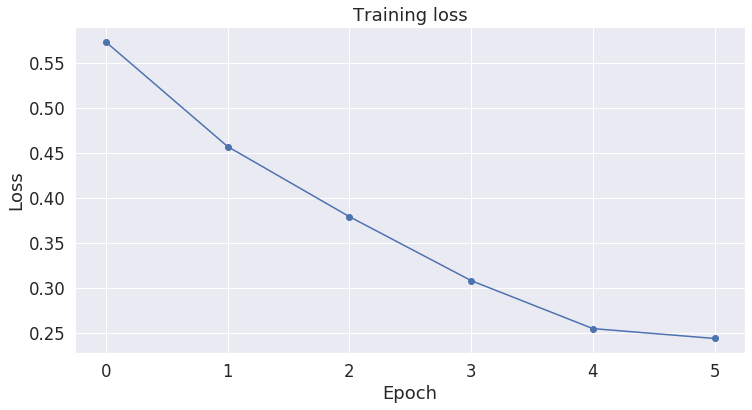

In [0]:
# Plot the learning curve.
plt.plot(loss_values, 'b-o')

# Label the plot.
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

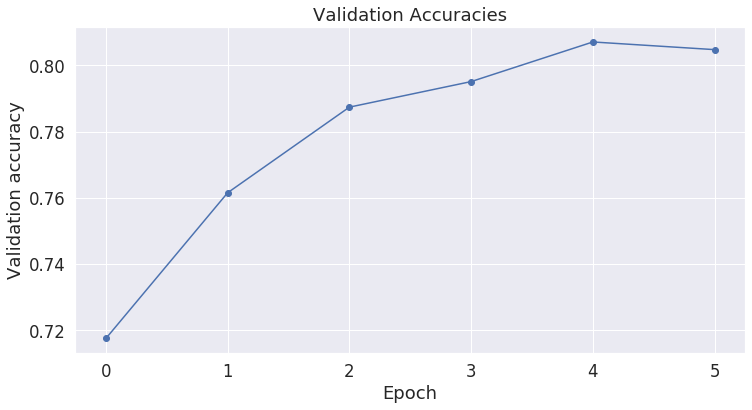

In [0]:
# Plot the learning curve.
plt.plot(validation_accuracies, 'b-o')

# Label the plot.
plt.title("Validation Accuracies")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")

plt.show()

# Saving The Model

In [0]:
import os

# Saving best-practices: if you use defaults names for the model, you can reload it using from_pretrained()

output_dir = './my_model_save/'

# Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving model to %s" % output_dir)

# Save a trained model, configuration and tokenizer using `save_pretrained()`.
# They can then be reloaded using `from_pretrained()`
model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
model_to_save.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

# Good practice: save your training arguments together with the trained model
#Both of these can be used for inferencing
#state_dict is recommended for inferencing as architecture is not needed
torch.save(model.state_dict(), './my_model_save/weights_only.pth')   #only the weights
torch.save(model, './my_model_save/entire_model.pth')    #weights along with the architecture

#For resuming training
args = {'epoch': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()}

torch.save(args, './my_model_save/training_args.bin')

Saving model to ./my_model_save/


/usr/local/lib/python3.6/dist-packages/torch/serialization.py:292: UserWarning: Couldn't retrieve source code for container of type RobertaForSequenceClassification. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't be checked "
/usr/local/lib/python3.6/dist-packages/torch/serialization.py:292: UserWarning: Couldn't retrieve source code for container of type RobertaModel. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't be checked "
/usr/local/lib/python3.6/dist-packages/torch/serialization.py:292: UserWarning: Couldn't retrieve source code for container of type RobertaEmbeddings. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't be checked "
/usr/local/lib/python3.6/dist-packages/torch/serialization.py:292: UserWarning: Couldn't retrieve source code for container of type Embedding. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't

In [0]:
!ls -l --block-size=K ./my_model_save/

total 1935416K
-rw-r--r-- 1 root root      1K Jan  1 11:47 added_tokens.json
-rw-r--r-- 1 root root      1K Jan  1 11:47 config.json
-rw-r--r-- 1 root root 323122K Jan  1 11:47 entire_model.pth
-rw-r--r-- 1 root root    446K Jan  1 11:47 merges.txt
-rw-r--r-- 1 root root 323114K Jan  1 11:47 pytorch_model.bin
-rw-r--r-- 1 root root      1K Jan  1 11:47 special_tokens_map.json
-rw-r--r-- 1 root root      1K Jan  1 11:47 tokenizer_config.json
-rw-r--r-- 1 root root 964706K Jan  1 11:47 training_args.bin
-rw-r--r-- 1 root root    878K Jan  1 11:47 vocab.json
-rw-r--r-- 1 root root 323114K Jan  1 11:47 weights_only.pth


In [0]:
!ls -l --block-size=M ./my_model_save/pytorch_model.bin

-rw-r--r-- 1 root root 316M Jan  1 11:47 ./my_model_save/pytorch_model.bin


In [0]:
!cp -r ./my_model_save/ "./drive/My Drive/MY PYTORCH MODELS/Distil RoBERTa (Sequence Classification on CoLA)"